In [475]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [476]:
print(df.isna().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [477]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Basing on the output of the info() method, it is possible to notice that the field *TotalCharges* is formatted as *object* rather than *float*. In order to ensure consistency during more complex analysis, it is necessary to convert the field *TotalCharges* as a number.

In [478]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)

float64


After converting the TotalCharges column into numeric, running the .info() method we can see that there are 11 rows with NULL value. Instead of dropping 11 rows, we hypotize to fill those values with the *average* value of *TotalCharges*.

In [479]:
avg_total_charges = round(df['TotalCharges'].mean(), 2)
df.loc[df['TotalCharges'].isna() == True, 'TotalCharges'] = avg_total_charges
print(df.loc[df['TotalCharges'] == avg_total_charges, ['customerID', 'TotalCharges']])

      customerID  TotalCharges
488   4472-LVYGI        2283.3
753   3115-CZMZD        2283.3
936   5709-LVOEQ        2283.3
1082  4367-NUYAO        2283.3
1340  1371-DWPAZ        2283.3
3331  7644-OMVMY        2283.3
3826  3213-VVOLG        2283.3
4380  2520-SGTTA        2283.3
5218  2923-ARZLG        2283.3
5744  1371-WEPDS        2283.3
6670  4075-WKNIU        2283.3
6754  2775-SEFEE        2283.3


We start analyzing the dataset by identifying if most of customers churn or not.

Churned customers: 1869
Customers who did not churn: 5174
Churn rate:  0.27


/tmp/ipykernel_3649/1352837837.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn_binary'] = df['Churn'].replace(values)


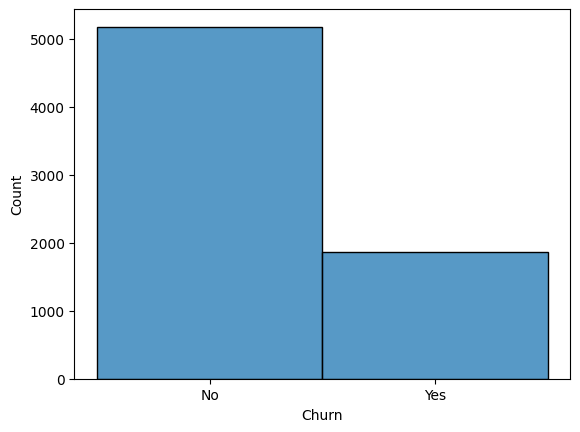

In [480]:
values = {'Yes': 1, 'No': 0}
df['Churn_binary'] = df['Churn'].replace(values)
churned_customers = (df['Churn_binary'] == 1).sum()
print('Churned customers:', churned_customers)
not_churned_customers = (df['Churn_binary']== 0).sum()
print('Customers who did not churn:', not_churned_customers)
churn_rate = round(churned_customers/(not_churned_customers + churned_customers), 2)
print('Churn rate: ', churn_rate)
sns.histplot(data = df, x = 'Churn')
plt.show()

The analysis clearly shows that only 27% of the total customers have churned. On the other hand, 73% of the customers did not churn during the observation period. To improve business results and competitiveness, it is necessary to further investigate why those customers decided to churn.

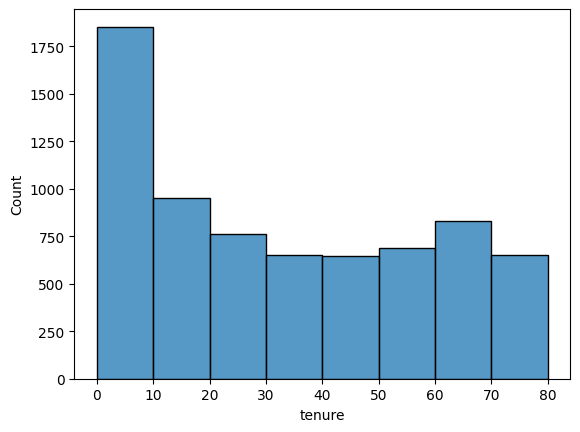

In [481]:
sns.histplot(data=df['tenure'], bins=range(0,81,10))
plt.show()

In [482]:
less_ten_months = (df['tenure']<=10).sum()
print('Customers who subscribed within the last 10 months:', less_ten_months)
between_50_60 = ((df['tenure']>=50)&(df['tenure']<=60)).sum()
between_60_70 = ((df['tenure']>=60)&(df['tenure']<=70)).sum()

Customers who subscribed within the last 10 months: 1970


Customers who have subscribed within the last 10 months are more than double than customers who subscribed within 10 and 20 months ago. This high numeric clearly indicates that something made 1970 customers to subscribe within the last 10 months. It is now necessary to further investigate what the causes of this sharp increase could have been.

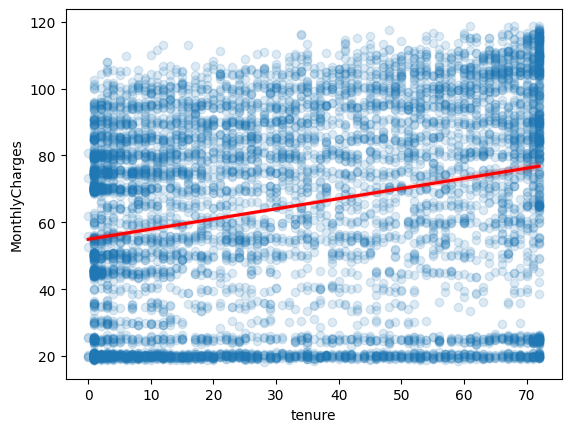

In [483]:
# tenure vs MonthlyCharges - Part 1
subdf = df.loc[:,['tenure', 'MonthlyCharges']]
sns.regplot(subdf, x='tenure', y='MonthlyCharges', scatter_kws={'alpha': 0.15}, line_kws=dict(color="r"))
plt.show()

There is a positive correlation between tenure and monthly charges. The hypothesis is that customers with higher tenure have added services over time, which we verify in the next section.

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, '(-0.073, 10.286]'),
  Text(1, 0, '(10.286, 20.571]'),
  Text(2, 0, '(20.571, 30.857]'),
  Text(3, 0, '(30.857, 41.143]'),
  Text(4, 0, '(41.143, 51.429]'),
  Text(5, 0, '(51.429, 61.714]'),
  Text(6, 0, '(61.714, 72.0]')])

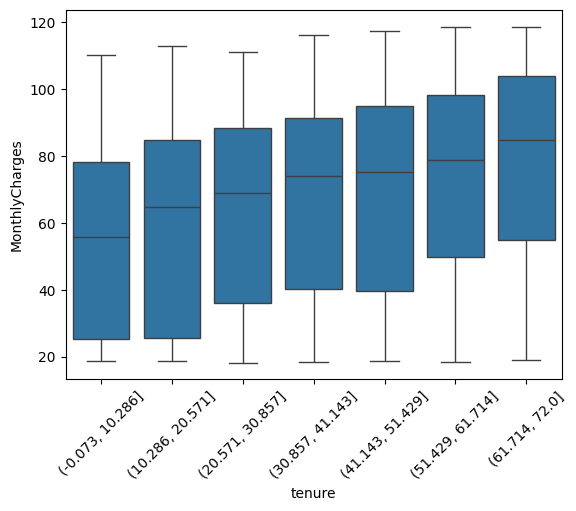

In [484]:
# tenure vs MonthlyCharges - Part 2
bins = pd.cut(df['tenure'], 7, right = True, include_lowest = True)
sns.boxplot(x=bins, y='MonthlyCharges', data=df)
plt.xticks(rotation=45)

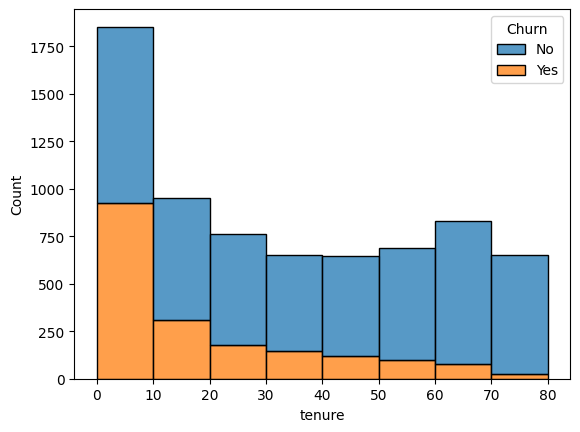

In [485]:
# (1) Relationship between churn and tenure
sns.histplot(data = df, x = 'tenure', hue = 'Churn', multiple = 'stack', bins = range(0,81,10))
plt.show()

In [486]:
churn_within_10 = ((df['Churn'] == 'Yes') & (df['tenure'] <= 10)).sum()
print('Customers who churned within first 10 months of subscription:', churn_within_10)
not_churn_within_10 = ((df['Churn'] == 'No') & (df['tenure'] <= 10)).sum()
print('Customers who did not churn within first 10 months of subscription:', not_churn_within_10)
churn_from_10 = ((df['Churn'] == 'Yes') & (df['tenure'] > 10)).sum()
print('Customers who churned from the 11th month of subscription:', churn_from_10)
churn_rate_10 = round(churn_within_10/(not_churn_within_10 + churn_within_10), 2)
print('First 10 months churn rate: ', churn_rate_10)

Customers who churned within first 10 months of subscription: 968
Customers who did not churn within first 10 months of subscription: 1002
Customers who churned from the 11th month of subscription: 901
First 10 months churn rate:  0.49


Within the first 10 months, almost 49% of customers churn. This number indicates that customers who subscribed within last 10 months decide to not further be subscribed.

In [487]:
print(df['OnlineSecurity'].unique())
print(df['OnlineBackup'].unique())
print(df['DeviceProtection'].unique())
print(df['TechSupport'].unique())
print(df['StreamingTV'].unique())
print(df['StreamingMovies'].unique())
values = {'Yes': 1, 'No': 0, 'No internet service': 0}
cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in cols:
  df[col] = df[col].replace(values).astype('Int64')

['No' 'Yes' 'No internet service']
['Yes' 'No' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']
['No' 'Yes' 'No internet service']


/tmp/ipykernel_3649/1608367777.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(values).astype('Int64')


Number of customers with no extra services that churned:  475
Number of customers with one extra service that churned:  442
Number of customers with all extra service that churned:  15


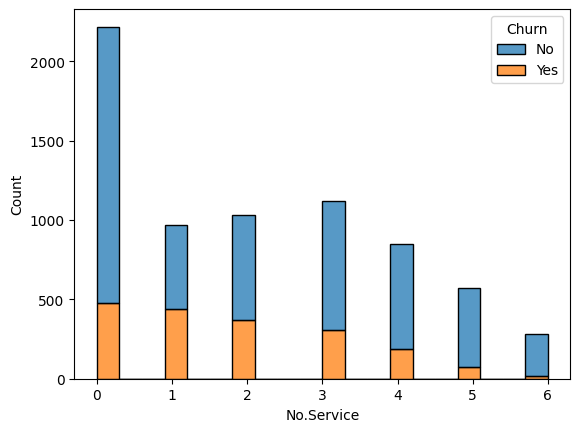

In [488]:
# (2) Relationship between churn and number of services
df['No.Service'] = df.loc[:, ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']].sum(axis=1)
sns.histplot(data = df, x='No.Service', hue = 'Churn', multiple = 'stack')
no_extra_service = ((df['No.Service'] == 0) & (df['Churn'] == 'Yes')).sum()
one_extra_service = ((df['No.Service'] == 1) & (df['Churn'] == 'Yes')).sum()
all_extra_service = ((df['No.Service'] == 6) & (df['Churn'] == 'Yes')).sum()
print('Number of customers with no extra services that churned: ', no_extra_service)
print('Number of customers with one extra service that churned: ', one_extra_service)
print('Number of customers with all extra service that churned: ', all_extra_service)

The more customers have extra services, the more the churn rate decreases.

No.Service
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn_binary, dtype: float64


<Axes: xlabel='No.Service', ylabel='Churn_binary'>

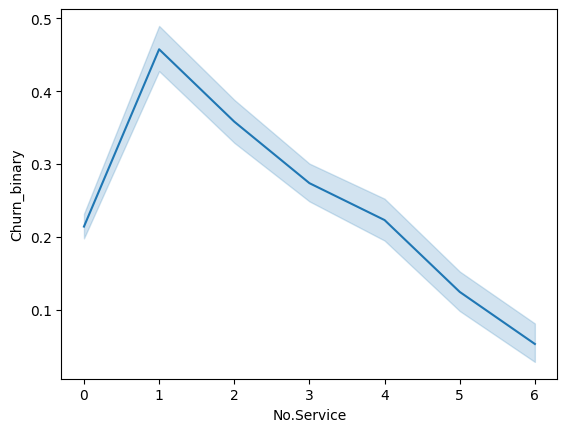

In [489]:
print(df.groupby('No.Service')['Churn_binary'].mean())
sns.lineplot(data = df, x = 'No.Service', y = 'Churn_binary')

As shown, the maximum churn rate (46%) is reached by customers with one extra service. As the number of extra services increases, churn rate drops until it reaches 5% for customers with all extra services.

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

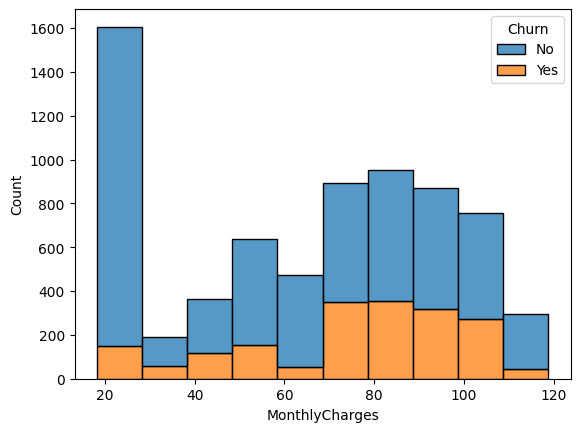

In [490]:
# (3) Relationship between churn and monthly charges - Part 1
sns.histplot(data = df, x = 'MonthlyCharges', hue = 'Churn', multiple = 'stack', bins = 10)

It is possible to notice that the number of customers who pay between 70 and 110 is much higher that all other monthly charges. Let's dive-in into the churn rate to analyze what is the maximum peak.

/tmp/ipykernel_3649/3121490010.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate = df.groupby('MonthlyCharges_bin')['Churn_binary'].mean()


<Axes: xlabel='MonthlyCharges_bin'>

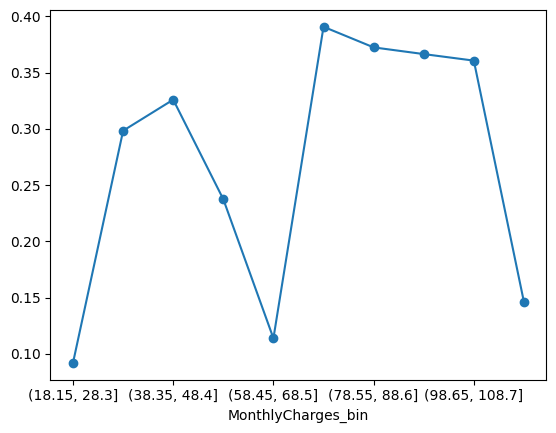

In [491]:
# (3) Relationship between churn and monthly charges - Part 2
df['MonthlyCharges_bin'] = pd.cut(df['MonthlyCharges'], bins=10)
churn_rate = df.groupby('MonthlyCharges_bin')['Churn_binary'].mean()
churn_rate.plot(kind='line', marker='o')

When the cost is little, the churn rate is the lowest (<10%) and reaches its maximum (38-39%) when the monthly charge is between 68.5 and 78.55.

['Month-to-month' 'One year' 'Two year']


<Axes: xlabel='Contract', ylabel='Count'>

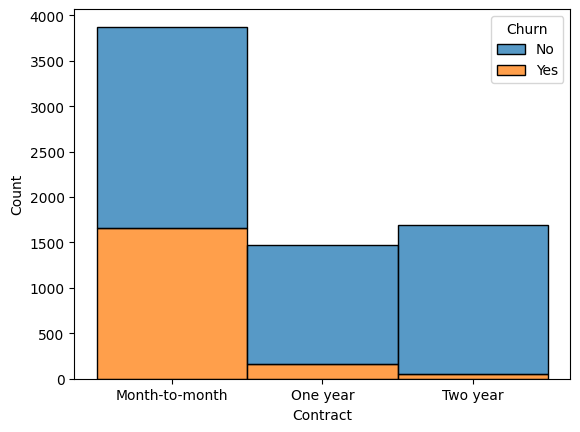

In [492]:
# (4) Relationship between churn and contract type
print(df['Contract'].unique())
sns.histplot(data = df, x = 'Contract', hue = 'Churn', multiple = 'stack')

The most of churns comes from customers who have been subscribed with a *month-to-month* contract type. Whereas, customers who subscribed with a two-year contract have the lowest churns.

In [493]:
no_senior = (df['SeniorCitizen'] == 0).sum()
print('No Senior:',no_senior)
senior = (df['SeniorCitizen'] == 1).sum()
print('Senior:', senior)

No Senior: 5901
Senior: 1142


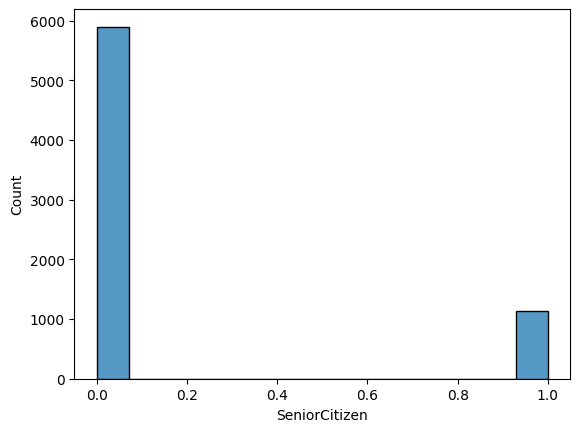

In [494]:
ax = sns.histplot(data=df, x='SeniorCitizen', stat = 'count')
plt.show()

The above displayed histogram, clearly shows that 5901 customers are not senior citizens, indicating that only approximately 19% of the total customers are seniors. It now necessary to analyze the churn rate of seniors.

In [495]:
print(round(df.groupby('SeniorCitizen')['Churn_binary'].mean(), 2))

SeniorCitizen
0    0.24
1    0.42
Name: Churn_binary, dtype: float64


Senior citizens churn at a rate of 42%, compared to 24% for non-senior customers, making age a relevant risk factor for churn.

In [496]:
print(df[df['TotalCharges'].isna() == True])

Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn, Churn_binary, No.Service, MonthlyCharges_bin]
Index: []

[0 rows x 24 columns]


# Key takeaways
1. Overall churn rate: **27%**. The problem is real and significant.
2. Customers in the first **10** months have a churn rate of **49%**: the onboarding phase is critical.
3. Monthly contract have a **high risk**. Two-year customers churn **almost zero**.
4. Each additional service reduces churn, from **46%** with one service to **5%** with six.
5. Seniors' churn at **42%** vs. 24% for non-seniors. Seniors represent a high-risk segment.

F1 score: 0.5457943925233645


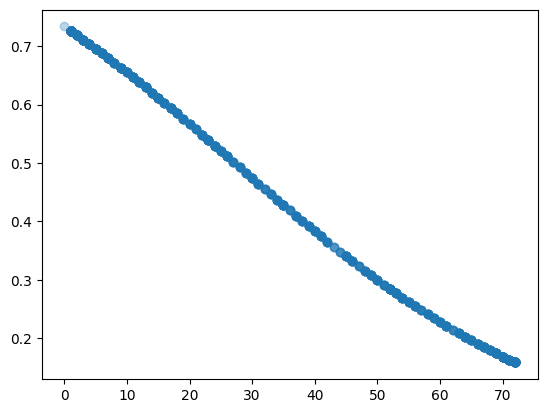

In [497]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

X = df['tenure'].values.reshape(-1,1)
y = df['Churn'].map({'Yes': 1, 'No':0})
log_reg = LogisticRegression(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]
print('F1 score:', f1_score(y_test, y_pred))
plt.scatter(X_test, y_prob, alpha=0.3)
plt.show()

In [498]:
df = pd.get_dummies(df, columns=['Contract'], drop_first = True)

# How tenure and contract affect churn?

X = df[['tenure'] + [col for col in df.columns if 'Contract_' in col]]
y = df['Churn'].map({'Yes': 1, 'No':0})
log_reg = LogisticRegression(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]
print('F1 score:', f1_score(y_test, y_pred))

F1 score: 0.5822566752799311


F1 score: 0.5990610328638498
ROC-AUC: 0.8205422484913101
              precision    recall  f1-score   support

           0       0.92      0.64      0.76      1036
           1       0.46      0.86      0.60       373

    accuracy                           0.70      1409
   macro avg       0.69      0.75      0.68      1409
weighted avg       0.80      0.70      0.71      1409



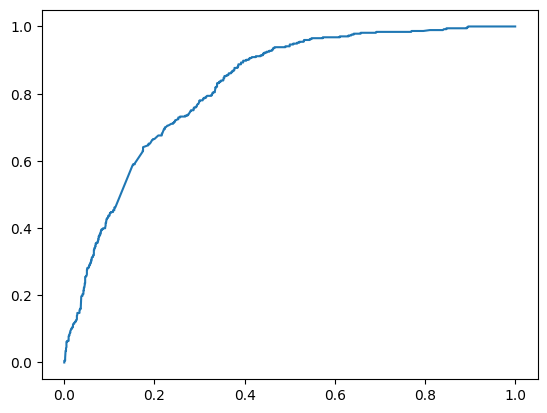

In [499]:
features = ['tenure', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract_One year', 'Contract_Two year']
X = df[features].values
y = df['Churn'].map({'Yes': 1, 'No':0})
log_reg = LogisticRegression(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
y_prob = log_reg.predict_proba(X_test)[:,1]
print('F1 score:', f1_score(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))
print(classification_report(y_test, y_pred))
fpr, tpr, threshold = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr)

The AUC-ROC of 0.82 indicates that the model discriminates well between churners and non-churners. The F1 of 0.60 at the default threshold reflects the imbalance of the dataset—27% churners vs. 73% non-churners.